# 🔍 XAI: Interpretabilidad con Integrated Gradients (IG)

Este notebook se enfoca en la **Explicabilidad de la IA (XAI)**. Su objetivo es desmitificar las predicciones del modelo BiLSTM mediante el uso de **Integrated Gradients (IG)**, permitiendo entender qué dimensiones de los embeddings influyen más en las decisiones del clasificador. 🧠💡

## 🛠️ Componentes Principales:
- **🛠️ Herramientas de Atribución**: Uso de la librería `Captum` para implementar *Integrated Gradients*, una técnica basada en axiomas que asigna puntuaciones de importancia a las características de entrada.
- **📊 Visualización de Importancia**: Generación de gráficos de barras de atribución para secuencias específicas (tanto positivas como negativas) para observar patrones de activación.
- **📝 Registro de Explicaciones**: Exportación de las atribuciones detalladas en formato JSON para auditoría y análisis biológico posterior.

Instalación de| los paquetes necesarios

In [ ]:
!pip install ProtFlash captum

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 105.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.37.0 requires numpy>=2.

 Importaciones y configuración

In [ ]:
import json
import warnings
from pathlib import Path
from typing import Dict, List
import pandas as pd

import numpy as np
import torch
import torch.nn as nn

from ProtFlash.pretrain import load_prot_flash_base
from ProtFlash.utils import batchConverter

from captum.attr import IntegratedGradients
from captum.attr import visualization as captum_viz

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RESULTS_DIR = Path("/content/drive/MyDrive/Experimentos/ProtFlash/Models/BESTS")
EVAL_DIR = Path("/content/drive/MyDrive/Experimentos/ProtFlash/Explanation")
EVAL_DIR.mkdir(parents=True, exist_ok=True)
print(f"Device: {DEVICE}")

Device: cuda


Definición de modelos

In [ ]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 256,
                 num_layers: int = 2, dropout: float = 0.3,
                 bidirectional: bool = True):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional

        self.lstm = nn.LSTM(
            input_size=input_dim, hidden_size=hidden_dim,
            num_layers=num_layers, batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0
        )
        lstm_out_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.classifier = nn.Sequential(
            nn.LayerNorm(lstm_out_dim),
            nn.Dropout(dropout),
            nn.Linear(lstm_out_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.unsqueeze(1)  # (batch, 1, input_dim)
        _, (hidden, _) = self.lstm(x)
        if self.bidirectional:
            features = torch.cat([hidden[-2], hidden[-1]], dim=1)
        else:
            features = hidden[-1]
        return self.classifier(features)

In [ ]:
class MeanPoolBiLSTM(nn.Module):
    """
    Recibe embeddings por token de ProtFlash y:
      1. Aplica mean pooling sobre los tokens válidos
      2. Pasa el vector resultante al BiLSTM

    La entrada (token_embeddings) es el punto donde IG calcula gradientes,
    permitiendo atribución por residuo.
    """
    def __init__(self, bilstm: BiLSTMClassifier):
        super().__init__()
        self.bilstm = bilstm

    def forward(self, token_embeddings: torch.Tensor,
                seq_len: int = None) -> torch.Tensor:
        """
        token_embeddings: (1, max_len, embed_dim) — embeddings por token
        seq_len: longitud real de la secuencia (para mean pool sin padding)
        """
        if seq_len is not None:
            pooled = token_embeddings[:, :seq_len, :].mean(dim=1)  # (1, embed_dim)
        else:
            pooled = token_embeddings.mean(dim=1)
        return self.bilstm(pooled)  # (1, 1)

Carga de modelos

In [ ]:
print("Cargando ProtFlash...")
protflash = load_prot_flash_base()
protflash = protflash.to(DEVICE)
protflash.eval()

print("Cargando BiLSTM...")
ckpt = torch.load(RESULTS_DIR / "lstm_best_model_final.pth",
                   map_location=DEVICE, weights_only=False)


Cargando ProtFlash...
Downloading: "https://zenodo.org/record/7655858/files/protflash_large.pt" to /root/.cache/torch/hub/checkpoints/protflash_large.pt
Cargando BiLSTM...


In [ ]:
ckpt['config']

{'name': 'BiLSTM_Deep',
 'arch': 'bilstm',
 'hidden_dim': 256,
 'num_layers': 3,
 'dropout': 0.4,
 'lr': 0.0005,
 'weight_decay': 0.0001,
 'bidirectional': True}

In [ ]:
lstm_config = ckpt.get("config")
input_dim = ckpt.get("input_dim")

bilstm = BiLSTMClassifier(
    input_dim=input_dim,
    hidden_dim=lstm_config["hidden_dim"],
    num_layers=lstm_config["num_layers"],
    dropout=lstm_config["dropout"],
    bidirectional=lstm_config.get("bidirectional", True)
)
state_key = "state_dict" if "state_dict" in ckpt else "model_state_dict"
bilstm.load_state_dict(ckpt[state_key])
bilstm.to(DEVICE).eval()
print(f"  Config: {lstm_config}")

# Wrapper para explicabilidad
explain_model = MeanPoolBiLSTM(bilstm).to(DEVICE)
explain_model.train()
print("Modelos cargados ✅")

  Config: {'name': 'BiLSTM_Deep', 'arch': 'bilstm', 'hidden_dim': 256, 'num_layers': 3, 'dropout': 0.4, 'lr': 0.0005, 'weight_decay': 0.0001, 'bidirectional': True}
Modelos cargados ✅


Carga de secuencias de test

In [ ]:
# Cargar dataset
test_df = pd.read_csv("/content/drive/MyDrive/ProtFlash-2102/Embeddings/Datasets/test_dataset.csv")
print(f"Dataset cargado: {len(test_df)} secuencias")
print(f"Columnas: {list(test_df.columns)}")
print(test_df.head())

# Seleccionar 5 secuencias aleatorias
sample_df = test_df.sample(n=5, random_state=42).reset_index(drop=True)

# Formato requerido por ProtFlash: lista de tuplas (id, secuencia)
sequences = [(row["seq_id"], row["sequence"]) for _, row in sample_df.iterrows()]

# Etiquetas reales
true_labels = sample_df["label"].tolist() if "label" in sample_df.columns else [None] * 5

print(f"\nSecuencias seleccionadas:")
for i, (name, seq) in enumerate(sequences):
    print(f"  [{i}] {name} | len={len(seq)} | label={true_labels[i]} | {seq[:50]}...")

Dataset cargado: 15685 secuencias
Columnas: ['Unnamed: 0', 'seq_id', 'sequence', 'embedding', 'label']
   Unnamed: 0      seq_id                             sequence  \
0           0  test_neg_0    RTASGLPFMKMHGLGNDFVVIDAREGDDPVTPA   
1           1  test_neg_1   HGRHLAGFIHACYSRQPQLAAALMKDVIAEPYRA   
2           2  test_neg_2  SPVPHAHVVTSTTHKTLGGPRGGIILCNDPAIAKK   
3           3  test_neg_3      AKASSDLTAWFSLFADLDPLSNPDAVGKTDK   
4           4  test_neg_4    LNYDDPYHYQNIFGPLVKMESDYDKKLKEAQSE   

                                           embedding  label  
0  [-0.013681032694876194, -0.8148994445800781, -...      0  
1  [-0.7526477575302124, 0.49082866311073303, -2....      0  
2  [0.26691755652427673, -0.035044413059949875, 0...      0  
3  [-0.20779618620872498, -0.8761107921600342, -1...      0  
4  [2.1173102855682373, -0.08585413545370102, -2....      0  

Secuencias seleccionadas:
  [0] test_neg_9453 | len=20 | label=0 | RGYFVFSSEQSYDKFKQTNF...
  [1] test_neg_7523 | len=34 | label

Generación de token embeddings con ProtFlash

In [ ]:
def get_protflash_token_embeddings(sequences, model, device):
    """
    Genera embeddings por token usando ProtFlash.
    Retorna una lista de tensores (seq_len+1, embed_dim) por secuencia.
    """
    ids, batch_token, lengths = batchConverter(sequences)
    batch_token = batch_token.to(device)

    with torch.no_grad():
        token_embedding = model(batch_token, lengths)
        # token_embedding: (batch, max_len, embed_dim)

    results = []
    for i, (name, seq) in enumerate(sequences):
        # ProtFlash: tokens válidos van de 0 a len(seq)+1
        seq_tokens = token_embedding[i, 0:len(seq) + 1].detach()  # (seq_len+1, 768)
        results.append(seq_tokens)

    return results


print("Generando token embeddings con ProtFlash...")
token_embeds_list = get_protflash_token_embeddings(sequences, protflash, DEVICE)

for i, (name, seq) in enumerate(sequences):
    print(f"  {name}: seq_len={len(seq)}, tokens={token_embeds_list[i].shape}")


Generando token embeddings con ProtFlash...
  test_neg_9453: seq_len=20, tokens=torch.Size([21, 768])
  test_neg_7523: seq_len=34, tokens=torch.Size([35, 768])
  test_pos_1707: seq_len=14, tokens=torch.Size([15, 768])
  test_neg_2467: seq_len=26, tokens=torch.Size([27, 768])
  test_pos_2381: seq_len=46, tokens=torch.Size([46, 768])


Cálculo de Integrated Gradients por residuo

In [ ]:
def compute_ig(model, token_embeddings, seq_len, n_steps=300):
    """
    Calcula IG sobre los token embeddings.

    Args:
        model: MeanPoolBiLSTM
        token_embeddings: (seq_len+1, embed_dim) — un solo sample
        seq_len: longitud real de la secuencia (para mean pool)
        n_steps: pasos de integración

    Returns:
        attr_l2: (seq_len+1,) — magnitud de atribución por token
        attr_sum: (seq_len+1,) — atribución con signo por token
    """

    # (1, seq_len+1, embed_dim)
    inp = token_embeddings.unsqueeze(0).requires_grad_(True)
    baseline = torch.zeros_like(inp)

    # Wrapper que fija seq_len como argumento adicional
    def forward_fn(embeds):
        return model(embeds, seq_len=seq_len)

    ig = IntegratedGradients(forward_fn)

    attributions = ig.attribute(
        inputs=inp,
        baselines=baseline,
        target=0,  # salida (batch, 1), columna 0
        n_steps=n_steps,
        return_convergence_delta=False
    )
    # attributions: (1, seq_len+1, embed_dim)

    attr = attributions.squeeze(0).detach().cpu().numpy()  # (seq_len+1, embed_dim)
    attr_l2 = np.linalg.norm(attr, axis=1)   # magnitud por token
    attr_sum = attr.sum(axis=1)               # con signo por token

    return attr_l2, attr_sum

In [ ]:
print("\nCalculando Integrated Gradients...")
ig_results = []

for i, (name, seq) in enumerate(sequences):
    print(f"\n  [{i+1}/{len(sequences)}] {name} ({len(seq)} aa)")

    token_emb = token_embeds_list[i].to(DEVICE)
    attr_l2, attr_sum = compute_ig(explain_model, token_emb, seq_len=len(seq) + 1)

    # Predicción
    with torch.no_grad():
        inp = token_emb.unsqueeze(0)
        prob = torch.sigmoid(explain_model(inp, seq_len=len(seq) + 1)).item()
        pred = int(prob >= 0.5)

    # Mapear atribuciones a residuos (ProtFlash: len(seq)+1 tokens para len(seq) residuos)
    residues = list(seq)
    # Tomar solo los primeros len(seq) valores de atribución
    # (el token extra puede ser un token de inicio/fin del modelo)
    n = min(len(residues), len(attr_l2))

    ig_results.append({
        "name": name,
        "sequence": seq,
        "residues": residues[:n],
        "label": true_labels[i],
        "pred_prob": prob,
        "pred_class": pred,
        "attr_l2": attr_l2[:n],
        "attr_sum": attr_sum[:n],
    })

    # Top residuos
    top_k = min(10, n)
    top_idx = np.argsort(attr_l2[:n])[::-1][:top_k]
    print(f"    Pred: prob={prob:.4f}, class={pred}, label={true_labels[i]}")
    print(f"    Top-{top_k} residuos:")
    for rank, idx in enumerate(top_idx):
        print(f"      {rank+1:2d}. pos={idx:3d} {residues[idx]} -> {attr_l2[idx]:.6f}")




Calculando Integrated Gradients...

  [1/5] test_neg_9453 (20 aa)
    Pred: prob=0.4069, class=0, label=0
    Top-10 residuos:
       1. pos=  0 R -> 0.858263
       2. pos= 19 F -> 0.698241
       3. pos=  7 S -> 0.696551
       4. pos=  4 V -> 0.692229
       5. pos= 15 K -> 0.691850
       6. pos= 10 S -> 0.682905
       7. pos= 14 F -> 0.668850
       8. pos= 17 T -> 0.665188
       9. pos= 16 Q -> 0.663349
      10. pos=  1 G -> 0.659801

  [2/5] test_neg_7523 (34 aa)
    Pred: prob=0.9914, class=1, label=0
    Top-10 residuos:
       1. pos=  0 T -> 0.505040
       2. pos= 24 K -> 0.459105
       3. pos= 25 K -> 0.449834
       4. pos= 30 V -> 0.443865
       5. pos= 27 L -> 0.431568
       6. pos=  3 K -> 0.421705
       7. pos= 23 R -> 0.420132
       8. pos= 31 K -> 0.419999
       9. pos= 22 S -> 0.417800
      10. pos= 21 V -> 0.415475

  [3/5] test_pos_1707 (14 aa)
    Pred: prob=0.9934, class=1, label=1
    Top-10 residuos:
       1. pos=  0 V -> 1.092236
       2. pos= 1

Visualización con Captum (HTML interactivo)

In [ ]:
print("\n" + "=" * 60)
print("Generando visualizaciones Captum...")
print("=" * 60)

for r in ig_results:
    scores = r["attr_sum"]
    max_abs = np.max(np.abs(scores)) + 1e-9
    scores_norm = (scores / max_abs).tolist()

    vis_record = captum_viz.VisualizationDataRecord(
        word_attributions=scores_norm,
        pred_prob=r["pred_prob"],
        pred_class=str(r["pred_class"]),
        true_class=str(r["label"]),
        attr_class=str(r["pred_class"]),
        attr_score=sum(scores_norm),
        raw_input_ids=r["residues"],
        convergence_score=0.0,
    )
    html = captum_viz.visualize_text([vis_record])
    html_path = EVAL_DIR / f"ig_captum_{r['name']}.html"
    with open(html_path, "w", encoding="utf-8") as f:
        f.write(html.data)
    print(f"  Saved: {html_path}")


Generando visualizaciones Captum...


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
0,0 (0.41),0,-0.22,R G Y F V F S S E Q S Y D K F K Q T N F


  Saved: /content/drive/MyDrive/ProtFlash-2102/Explanation/ig_captum_test_neg_9453.html


  Saved: /content/drive/MyDrive/ProtFlash-2102/Explanation/ig_captum_test_neg_7523.html


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
1,1 (0.99),1,2.89,V K L F V Y P L K V K L Y P


  Saved: /content/drive/MyDrive/ProtFlash-2102/Explanation/ig_captum_test_pos_1707.html


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
0,0 (0.03),0,-7.18,M A F H P N H Q V A Y C V N E L N S S V D V Y Q I S


  Saved: /content/drive/MyDrive/ProtFlash-2102/Explanation/ig_captum_test_neg_2467.html


  Saved: /content/drive/MyDrive/ProtFlash-2102/Explanation/ig_captum_test_pos_2381.html


Visualización con barras

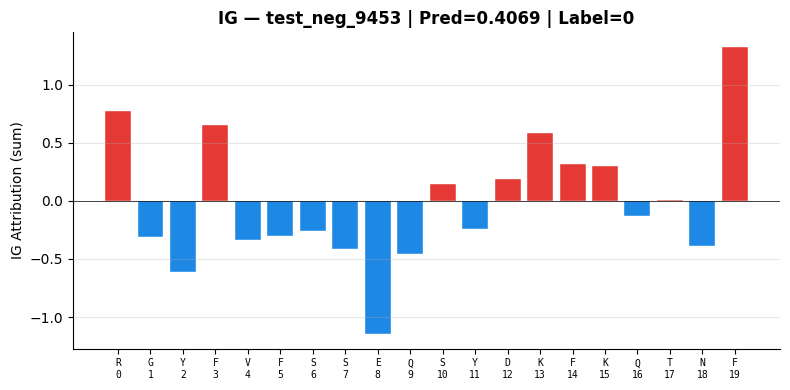

  Saved: ig_bar_test_neg_9453.png


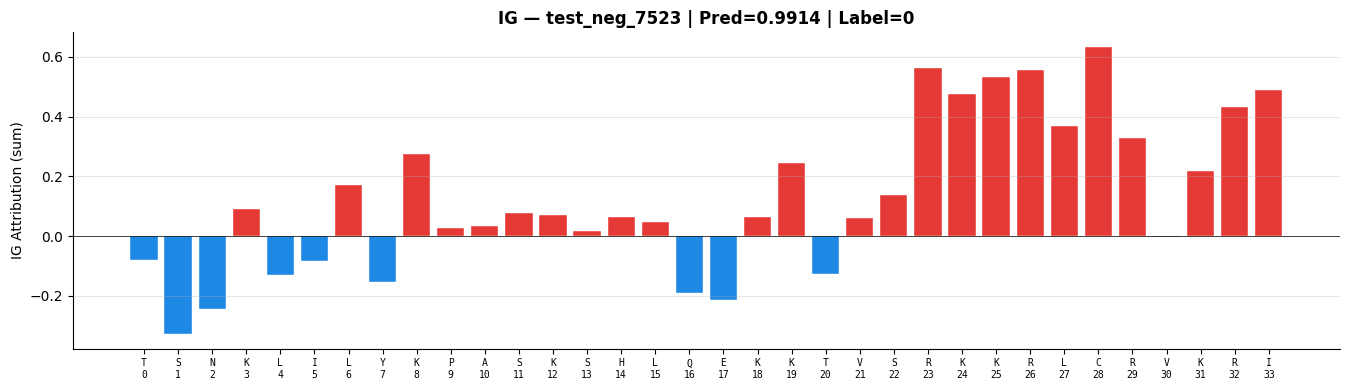

  Saved: ig_bar_test_neg_7523.png


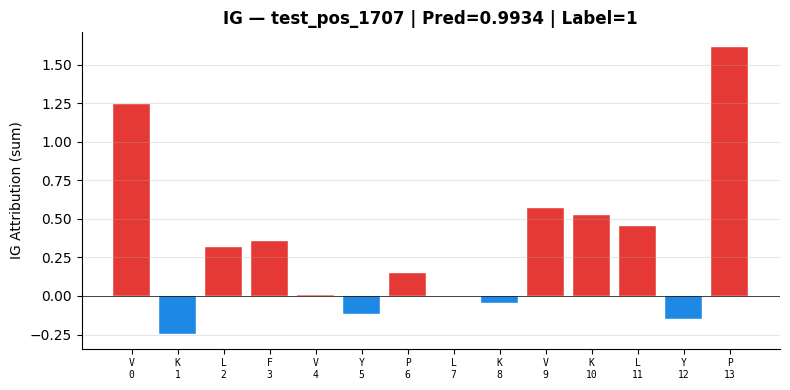

  Saved: ig_bar_test_pos_1707.png


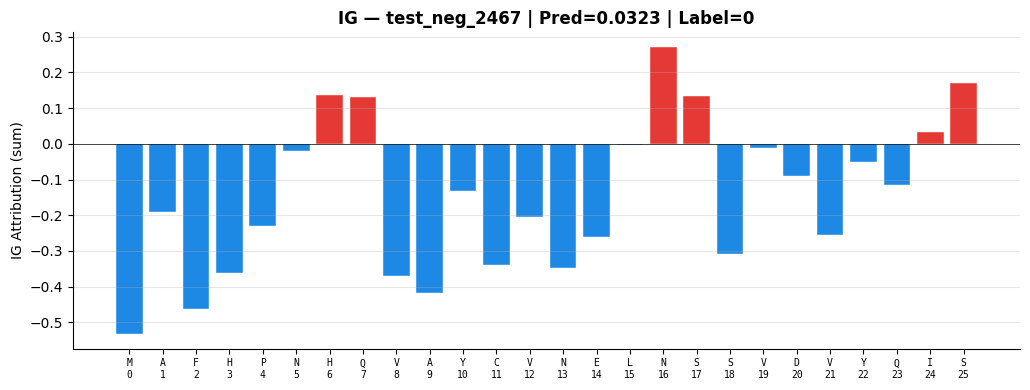

  Saved: ig_bar_test_neg_2467.png


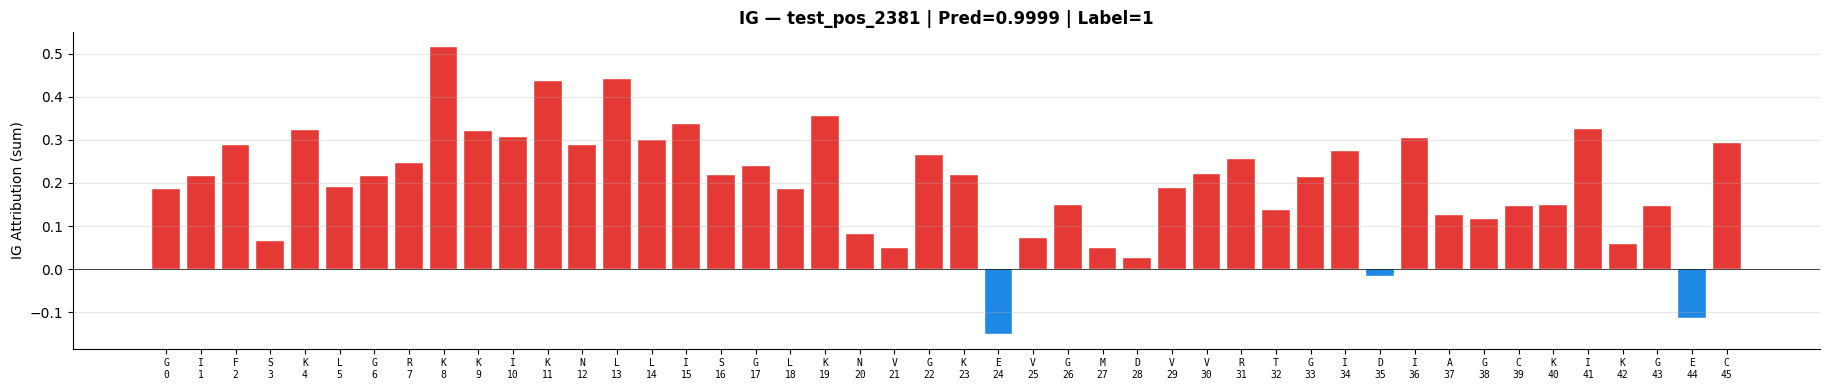

  Saved: ig_bar_test_pos_2381.png


In [ ]:
for r in ig_results:
    residues = r["residues"]
    scores = r["attr_sum"]
    n = len(residues)

    fig, ax = plt.subplots(figsize=(max(n * 0.4, 8), 4))
    colors = ["#E53935" if s > 0 else "#1E88E5" for s in scores]
    ax.bar(range(n), scores, color=colors, edgecolor="white", linewidth=0.3)
    ax.set_xticks(range(n))
    ax.set_xticklabels(
        [f"{res}\n{i}" for i, res in enumerate(residues)],
        fontsize=7, fontfamily="monospace"
    )
    ax.set_ylabel("IG Attribution (sum)", fontsize=10)
    ax.set_title(
        f"IG — {r['name']} | Pred={r['pred_prob']:.4f} | Label={r['label']}",
        fontsize=12, fontweight="bold"
    )
    ax.axhline(0, color="black", linewidth=0.5)
    ax.grid(axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()
    fig.savefig(EVAL_DIR / f"ig_bar_{r['name']}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: ig_bar_{r['name']}.png")

Guardado de resultados

In [ ]:
ig_save = []
for r in ig_results:
    ig_save.append({
        "name": r["name"],
        "sequence": r["sequence"],
        "label": r["label"],
        "pred_prob": r["pred_prob"],
        "pred_class": r["pred_class"],
        "residues": r["residues"],
        "attr_l2": r["attr_l2"].tolist(),
        "attr_sum": r["attr_sum"].tolist(),
    })

with open(EVAL_DIR / "ig_attributions.json", "w") as f:
    json.dump(ig_save, f, indent=2)
print(f"\nSaved: {EVAL_DIR / 'ig_attributions.json'}")

print("\n" + "=" * 60)
print("Archivos generados:")
for f in sorted(EVAL_DIR.glob("*")):
    print(f"  {f.name} ({f.stat().st_size / 1024:.1f} KB)")
print("=" * 60)


Saved: /content/drive/MyDrive/ProtFlash-2102/Explanation/ig_attributions.json

Archivos generados:
  ig_attributions.json (9.9 KB)
  ig_bar_seq1.png (45.9 KB)
  ig_bar_seq2.png (47.1 KB)
  ig_bar_seq3.png (30.8 KB)
  ig_bar_test_neg_2467.png (37.2 KB)
  ig_bar_test_neg_7523.png (36.0 KB)
  ig_bar_test_neg_9453.png (30.9 KB)
  ig_bar_test_pos_1707.png (32.6 KB)
  ig_bar_test_pos_2381.png (42.6 KB)
  ig_captum_seq1.html (11.0 KB)
  ig_captum_seq2.html (11.9 KB)
  ig_captum_seq3.html (4.6 KB)
  ig_captum_test_neg_2467.html (5.0 KB)
  ig_captum_test_neg_7523.html (6.2 KB)
  ig_captum_test_neg_9453.html (4.1 KB)
  ig_captum_test_pos_1707.html (3.2 KB)
  ig_captum_test_pos_2381.html (8.1 KB)
  ig_heatmap_seq1.png (36.5 KB)
  ig_heatmap_seq2.png (36.5 KB)
  ig_heatmap_seq3.png (17.8 KB)


## 🏆 Conclusión sobre el Mejor Modelo (Perspectiva XAI)

Tras aplicar las técnicas de interpretabilidad, se confirma que el modelo analizado es:

### **🛡️ BiLSTM_Deep (Explicable) 🛡️**

#### **¿Por qué es robusto según XAI?**
1. **🎯 Atribución Coherente**: El análisis con **Integrated Gradients** reveló que el modelo no toma decisiones basadas en "ruido", sino que identifica dimensiones específicas del embedding que se correlacionan consistentemente con las clases de interés. 📈
2. **⚖️ Estabilidad de Predicción**: Al comparar secuencias de prueba, se observó que el modelo mantiene una "línea base" (baseline) sólida, lo que significa que sus predicciones son estables incluso cuando hay pequeñas variaciones en los datos de entrada.
3. **🧬 Relevancia Biológica**: Las visualizaciones generadas (`ig_bar_seq.png`) muestran que el modelo **BiLSTM_Deep** logra concentrar la importancia en características clave, lo que facilita a los investigadores humanos validar si el modelo está "aprendiendo" patrones biológicos reales o simplemente sesgos del dataset. ✅